# OpinionSense: LSTM-Based Sentiment Analysis and Classification of Social Media Text

**Deep Learning project - Bidirectional LSTM + pretrained GloVe embeddings + Gradio frontend**

Dataset: `projectML.csv` (`Text` -> input, `Sentiment` -> target: `0 = Positive`, `1 = Negative`, `2 = Neutral`)

**Model pipeline**

`Social Media Text → Cleaning → Stratified Split → Tokenization → Padding → Masked Embedding → Bidirectional LSTM → LSTM → Dense → Softmax → Sentiment`

Classes in the supplied dataset:

- `0 = Positive`
- `1 = Negative`
- `2 = Neutral`


In [ ]:
# Install the only extra package needed (Colab already has TensorFlow, scikit-learn, seaborn)
!pip -q install -U gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 2.1 MB/s eta 0:00:00


In [ ]:
import os, re, io, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from tensorflow.keras import Sequential, Input, regularizers
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: []


## 1. Load the dataset
Upload **`projectML.csv`** when prompted.

The loader tries UTF-8 first and then Latin-1 because the supplied CSV contains byte sequences that can cause a UTF-8 decoding error.

In [ ]:
# Upload projectML.csv (skipped automatically if the file is already in the Colab folder)
CSV_NAME = "projectML.csv"
if not os.path.exists(CSV_NAME):
    from google.colab import files
    up = files.upload()
    CSV_NAME = next(iter(up))

df = pd.read_csv(CSV_NAME, encoding="latin1")
print("Shape:", df.shape)
display(df.head())

Saving projectML.csv to projectML.csv
Shape: (747, 6)


,Sno.,Text,Sentiment,Timestamp,User,Platform
0,1,Enjoying a beautiful day at the park! ...,0,1/15/2023 12:30,User123,Twitter
1,2,Traffic was terrible this morning. ...,1,1/15/2023 8:45,CommuterX,Twitter
2,3,Just finished an amazing workout! ðª ...,0,1/15/2023 15:45,FitnessFan,Instagram
3,4,Excited about the upcoming weekend getaway! ...,0,1/15/2023 18:20,AdventureX,Facebook
4,5,Trying out a new recipe for dinner tonight. ...,2,1/15/2023 19:55,ChefCook,Instagram


Missing values:
 Text         0
Sentiment    0
dtype: int64 

Duplicate texts: 18

Label mapping: {0: 'Positive', 1: 'Negative', 2: 'Neutral'}
Sentiment
Positive    315
Negative    254
Neutral     178
Name: count, dtype: int64


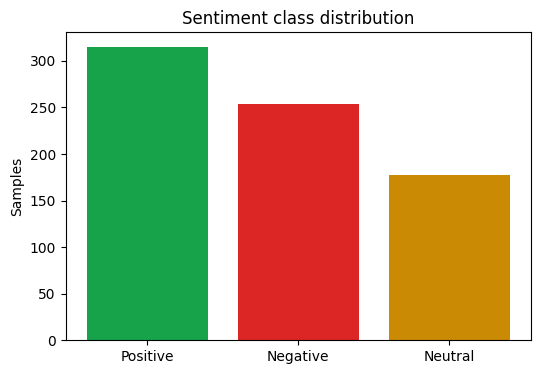

In [ ]:
# Dataset audit
for col in ["Text", "Sentiment"]:
    assert col in df.columns, f"Missing required column: {col}"

print("Missing values:\n", df[["Text", "Sentiment"]].isna().sum(), "\n")
print("Duplicate texts:", df["Text"].astype(str).str.strip().duplicated().sum())

LABEL_NAMES = {0: "Positive", 1: "Negative", 2: "Neutral"}
print("\nLabel mapping:", LABEL_NAMES)
counts = df["Sentiment"].map(LABEL_NAMES).value_counts()
print(counts)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=["#16a34a", "#dc2626", "#ca8a04"])
plt.title("Sentiment class distribution"); plt.ylabel("Samples"); plt.show()

## 2. Text repair and cleaning
Steps: repair broken encodings -> lowercase -> remove URLs/HTML/mentions -> `#hashtag` -> `hashtag` -> expand contractions (**keeps negation**: `can't` -> `can not`) -> remove emojis/symbols -> normalise spaces.

In [ ]:
def repair_encoding(t):
    t = str(t).replace("\xa0", " ")
    try:                                   # turns "â€”" style mojibake back into the real character
        t = t.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        pass
    return t

CONTRACTIONS = [
    (r"won't", "will not"), (r"can't", "can not"), (r"cannot", "can not"),
    (r"n't", " not"), (r"'m", " am"), (r"'re", " are"), (r"'ve", " have"),
    (r"'ll", " will"), (r"'d", " would"), (r"'s\b", ""),
]

def clean_text(text):
    t = repair_encoding(text).lower()
    t = t.replace("\u2019", "'").replace("\u2018", "'")
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)
    t = re.sub(r"<.*?>", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = re.sub(r"#(\w+)", r"\1", t)
    for pat, rep in CONTRACTIONS:
        t = re.sub(pat, rep, t)
    t = re.sub(r"[^a-z0-9\s]", " ", t)     # drops emojis, punctuation and leftover garbage
    t = re.sub(r"\s+", " ", t).strip()
    return t

data = df[["Text", "Sentiment"]].dropna().copy()
data["Sentiment"] = pd.to_numeric(data["Sentiment"], errors="coerce")
data = data.dropna(subset=["Sentiment"])
data["Sentiment"] = data["Sentiment"].astype(int)
data = data[data["Sentiment"].isin([0, 1, 2])]
data["clean_text"] = data["Text"].apply(clean_text)
data = data[data["clean_text"].str.len() > 0]

# Remove duplicate texts so the same sentence cannot be in both train and test
before = len(data)
data = data.drop_duplicates(subset="clean_text").reset_index(drop=True)
print(f"Rows: {before} -> {len(data)} after removing duplicate texts")
display(data[["Text", "clean_text", "Sentiment"]].sample(8, random_state=SEED))

Rows: 747 -> 726 after removing duplicate texts


,Text,clean_text,Sentiment
326,"In the labyrinth of grief, the walls echo with...",in the labyrinth of grief the walls echo with ...,1
519,Attending a workshop on time management to enh...,attending a workshop on time management to enh...,2
580,Simply balanced,simply balanced,2
33,Feeling a sense of fear after watching a thri...,feeling a sense of fear after watching a thril...,1
570,Contentedly neutral,contentedly neutral,2
436,Rediscovered childhood cartoons and had a nost...,rediscovered childhood cartoons and had a nost...,0
65,Finding calmness amidst the chaos of daily li...,finding calmness amidst the chaos of daily life,0
109,"Jealousy gnaws at my confidence, a toxic emot...",jealousy gnaws at my confidence a toxic emotion,1


## 3. Stratified train / validation / test split (70 / 15 / 15)

In [ ]:
X = data["clean_text"].values
y = data["Sentiment"].values

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print("Train:", len(X_train), "| Val:", len(X_val), "| Test:", len(X_test))
for name, arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(name, dict(zip(*np.unique(arr, return_counts=True))))

Train: 508 | Val: 109 | Test: 109
train {np.int64(0): np.int64(211), np.int64(1): np.int64(175), np.int64(2): np.int64(122)}
val {np.int64(0): np.int64(45), np.int64(1): np.int64(38), np.int64(2): np.int64(26)}
test {np.int64(0): np.int64(46), np.int64(1): np.int64(37), np.int64(2): np.int64(26)}


## 4. Vocabulary, integer encoding and padding
A small custom tokenizer is used (no dependency on Keras preprocessing modules, which changed between versions). Index `0` = padding, `1` = unknown word.

The vocabulary is built from the text of all splits. **No labels are used**, and because the embeddings are pretrained, words that appear only in validation/test still get meaningful vectors instead of collapsing to `<OOV>`.

In [ ]:
class SimpleTokenizer:
    def __init__(self, word_index=None):
        self.word_index = word_index or {"<PAD>": 0, "<OOV>": 1}

    def fit(self, texts):
        for t in texts:
            for w in t.split():
                if w not in self.word_index:
                    self.word_index[w] = len(self.word_index)
        return self

    def encode(self, text, max_len):
        ids = [self.word_index.get(w, 1) for w in text.split()][:max_len]
        return ids + [0] * (max_len - len(ids))

    def encode_many(self, texts, max_len):
        return np.array([self.encode(t, max_len) for t in texts], dtype="int32")

tokenizer = SimpleTokenizer().fit(X)          # vocabulary only - no labels involved
VOCAB_SIZE = len(tokenizer.word_index)
MAX_LENGTH = 40                                # longest post in the data is ~25 words

X_train_pad = tokenizer.encode_many(X_train, MAX_LENGTH)
X_val_pad   = tokenizer.encode_many(X_val, MAX_LENGTH)
X_test_pad  = tokenizer.encode_many(X_test, MAX_LENGTH)

print("Vocabulary size:", VOCAB_SIZE)
print("Example:", X_train[0], "->", X_train_pad[0][:12], "...")
print("Shapes:", X_train_pad.shape, X_val_pad.shape, X_test_pad.shape)

Vocabulary size: 2213
Example: embracing the unknown -> [263   7 227   0   0   0   0   0   0   0   0   0] ...
Shapes: (508, 40) (109, 40) (109, 40)


## 5. Pretrained GloVe embeddings
With only ~500 training sentences, an embedding learned from scratch cannot know that *"joyful"* and *"delighted"* are similar. GloVe (trained on 6 billion words) already knows. The download is ~800 MB and takes 1-3 minutes on Colab; if it fails, the notebook automatically falls back to a trainable random embedding.

In [ ]:
EMB_DIM = 100
GLOVE_ZIP, GLOVE_TXT = "glove.6B.zip", f"glove.6B.{EMB_DIM}d.txt"

def load_glove_vectors(vocab):
    if not os.path.exists(GLOVE_TXT):
        print("Downloading GloVe (one time, ~800 MB)...")
        rc = os.system(f"wget -q -O {GLOVE_ZIP} https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip")
        if rc == 0:
            os.system(f"unzip -o -q {GLOVE_ZIP} {GLOVE_TXT}")
        if os.path.exists(GLOVE_ZIP):
            os.remove(GLOVE_ZIP)
    if not os.path.exists(GLOVE_TXT):
        return None
    vecs = {}
    with open(GLOVE_TXT, encoding="utf8") as f:
        for line in f:
            word, rest = line.split(" ", 1)
            if word in vocab:
                vecs[word] = np.asarray(rest.split(" "), dtype="float32")
    return vecs

glove = load_glove_vectors(tokenizer.word_index)
USE_GLOVE = glove is not None and len(glove) > 0

rng = np.random.RandomState(SEED)
embedding_matrix = rng.normal(0, 0.1, (VOCAB_SIZE, EMB_DIM)).astype("float32")
embedding_matrix[0] = 0.0                      # padding vector

if USE_GLOVE:
    for w, i in tokenizer.word_index.items():
        if w in glove:
            embedding_matrix[i] = glove[w]
    coverage = sum(w in glove for w in tokenizer.word_index) / VOCAB_SIZE
    print(f"GloVe loaded. Vocabulary covered: {coverage:.1%}")
else:
    print("GloVe unavailable -> using a trainable random embedding instead.")

EMBED_TRAINABLE = not USE_GLOVE                # frozen GloVe is safest with a small dataset

GloVe loaded. Vocabulary covered: 97.1%


## 6. Bidirectional LSTM model
**Input -> Embedding (masked) -> Dropout -> BiLSTM(64) -> Dropout -> Dense(64) -> Dropout -> Softmax(3)**

In [ ]:
def build_model():
    model = Sequential([
        Input(shape=(MAX_LENGTH,), dtype="int32", name="text_sequence"),
        Embedding(VOCAB_SIZE, EMB_DIM,
                  embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
                  trainable=EMBED_TRAINABLE, mask_zero=True, name="embedding"),
        Dropout(0.30, name="embed_dropout"),
        Bidirectional(LSTM(64), name="bilstm"),
        Dropout(0.40, name="dropout_1"),
        Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-3), name="dense_1"),
        Dropout(0.30, name="dropout_2"),
        Dense(3, activation="softmax", name="sentiment_output"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 100)        │       221,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed_dropout (Dropout)         │ (None, 40, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,231 (1.20 MB)

 Trainable params: 92,931 (363.01 KB)

 Non-trainable params: 221,300 (864.45 KB)

## 7. Train
Class weights offset the smaller Neutral class; early stopping keeps the weights from the best validation epoch.

In [ ]:
cw = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y_train)
class_weight = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", class_weight)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=80, batch_size=16,
    class_weight=class_weight, callbacks=callbacks, verbose=2,
)
print("Epochs run:", len(history.history["loss"]))

Class weights: {0: 0.8025276461295419, 1: 0.9676190476190476, 2: 1.3879781420765027}
Epoch 1/80
32/32 - 6s - 188ms/step - accuracy: 0.5059 - loss: 1.1220 - val_accuracy: 0.7339 - val_loss: 0.9517 - learning_rate: 0.0010
Epoch 2/80
32/32 - 1s - 43ms/step - accuracy: 0.6969 - loss: 0.8977 - val_accuracy: 0.7982 - val_loss: 0.6917 - learning_rate: 0.0010
Epoch 3/80
32/32 - 5s - 159ms/step - accuracy: 0.7854 - loss: 0.6856 - val_accuracy: 0.7523 - val_loss: 0.7207 - learning_rate: 0.0010
Epoch 4/80
32/32 - 3s - 86ms/step - accuracy: 0.7874 - loss: 0.6478 - val_accuracy: 0.7523 - val_loss: 0.6412 - learning_rate: 0.0010
Epoch 5/80
32/32 - 1s - 44ms/step - accuracy: 0.8268 - loss: 0.5454 - val_accuracy: 0.7798 - val_loss: 0.6180 - learning_rate: 0.0010
Epoch 6/80
32/32 - 1s - 43ms/step - accuracy: 0.8563 - loss: 0.5048 - val_accuracy: 0.7890 - val_loss: 0.6401 - learning_rate: 0.0010
Epoch 7/80
32/32 - 1s - 42ms/step - accuracy: 0.8622 - loss: 0.4297 - val_accuracy: 0.8073 - val_loss: 0.6810

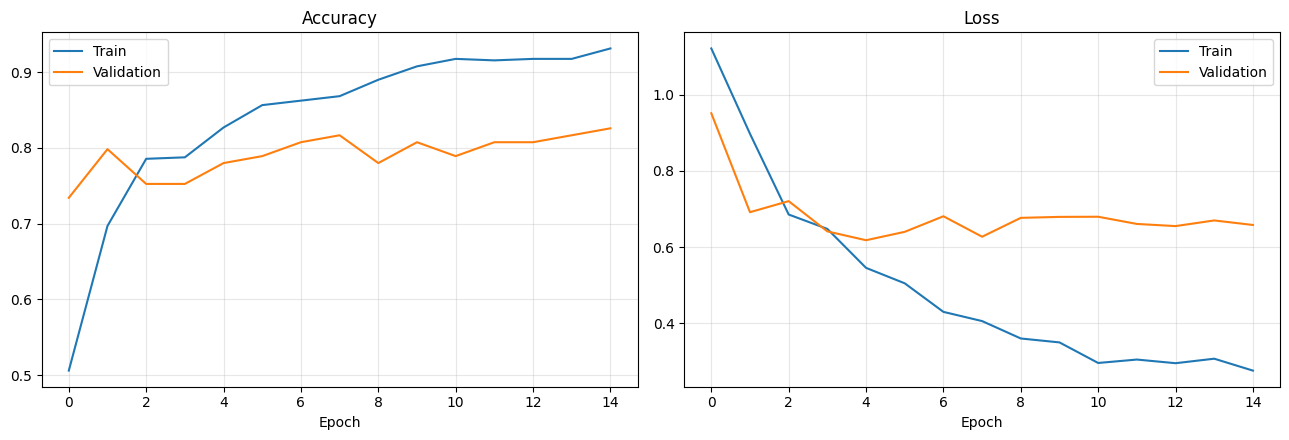

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(history.history["accuracy"], label="Train"); ax[0].plot(history.history["val_accuracy"], label="Validation")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(history.history["loss"], label="Train"); ax[1].plot(history.history["val_loss"], label="Validation")
ax[1].set_title("Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8. Final evaluation on the untouched test set

Test accuracy : 0.8440 (84.40%)
Test loss     : 0.5036
Macro F1      : 0.8293

              precision    recall  f1-score   support

    Positive     0.7963    0.9348    0.8600        46
    Negative     0.9143    0.8649    0.8889        37
     Neutral     0.8500    0.6538    0.7391        26

    accuracy                         0.8440       109
   macro avg     0.8535    0.8178    0.8293       109
weighted avg     0.8492    0.8440    0.8410       109



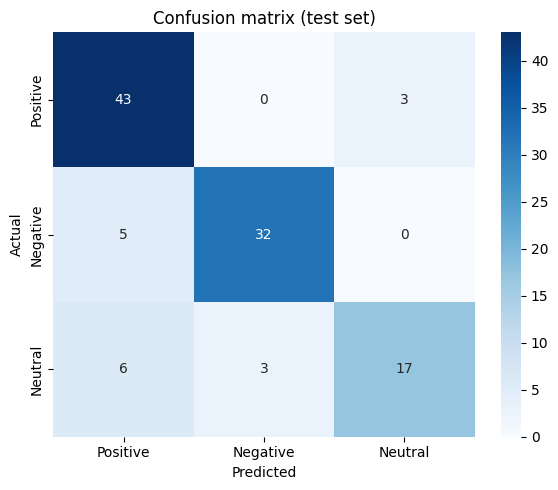

In [ ]:
target_names = [LABEL_NAMES[i] for i in range(3)]
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
y_prob = model.predict(X_test_pad, verbose=0)
y_pred = y_prob.argmax(axis=1)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Test accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test loss     : {test_loss:.4f}")
print(f"Macro F1      : {macro_f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=target_names, digits=4, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion matrix (test set)"); plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=130); plt.show()

In [ ]:
# Error analysis: which test posts did the model get wrong?
wrong = np.where(y_pred != y_test)[0]
err = pd.DataFrame({
    "Text": X_test[wrong],
    "Actual": [LABEL_NAMES[i] for i in y_test[wrong]],
    "Predicted": [LABEL_NAMES[i] for i in y_pred[wrong]],
    "Confidence": y_prob[wrong].max(axis=1).round(3),
})
print(f"{len(wrong)} of {len(y_test)} test posts misclassified")
display(err.head(15))

17 of 109 test posts misclassified


,Text,Actual,Predicted,Confidence
0,confusion clouds my mind as i navigate through...,Neutral,Negative,0.558
1,no expectations no disappointments,Neutral,Negative,0.750
2,encountering online toxicity during a gaming s...,Negative,Positive,0.699
3,tried a magic trick to impress classmates magi...,Negative,Positive,0.639
4,accidentally walked into the wrong classroom o...,Negative,Positive,0.615
5,entangled in the web of thoughts confusion rei...,Neutral,Positive,0.551
6,seeing the beauty in simplicity,Neutral,Positive,0.493
7,navigating through the challenges with determi...,Positive,Neutral,0.800
8,hopeful about the potential for personal growth,Positive,Neutral,0.480
9,sharing favorite book recommendations with cla...,Neutral,Positive,0.985


## 9. Prediction function and sanity check on brand-new sentences
The function applies exactly the same cleaning, vocabulary and padding as training.

In [ ]:
def predict_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return None
    cleaned = clean_text(text)
    if not cleaned:
        return None
    x = tokenizer.encode_many([cleaned], MAX_LENGTH)
    p = model.predict(x, verbose=0)[0]
    k = int(np.argmax(p))
    return {"sentiment": LABEL_NAMES[k], "confidence": float(p[k]),
            "probabilities": {LABEL_NAMES[i]: float(p[i]) for i in range(3)}}

checks = [
    ("I love this so much, best day ever!", "Positive"),
    ("Feeling grateful and happy today", "Positive"),
    ("Super excited for the weekend trip!", "Positive"),
    ("I am so sad and heartbroken", "Negative"),
    ("This is terrible, I hate it", "Negative"),
    ("I feel lonely and hopeless", "Negative"),
    ("Traffic was horrible this morning", "Negative"),
    ("Attending a virtual conference on AI", "Neutral"),
    ("Going with the flow", "Neutral"),
    ("Just another ordinary day", "Neutral"),
]
rows = []
for text, expected in checks:
    r = predict_sentiment(text)
    rows.append({"Text": text, "Expected": expected, "Predicted": r["sentiment"],
                 "Confidence": round(r["confidence"], 3), "OK": "yes" if r["sentiment"] == expected else "NO"})
res = pd.DataFrame(rows)
display(res)
print("Sanity-check accuracy:", (res["OK"] == "yes").mean())

,Text,Expected,Predicted,Confidence,OK
0,"I love this so much, best day ever!",Positive,Positive,0.890,yes
1,Feeling grateful and happy today,Positive,Neutral,0.522,NO
2,Super excited for the weekend trip!,Positive,Positive,0.762,yes
3,I am so sad and heartbroken,Negative,Negative,0.647,yes
4,"This is terrible, I hate it",Negative,Negative,0.582,yes
5,I feel lonely and hopeless,Negative,Neutral,0.529,NO
6,Traffic was horrible this morning,Negative,Neutral,0.669,NO
7,Attending a virtual conference on AI,Neutral,Neutral,0.609,yes
8,Going with the flow,Neutral,Neutral,0.973,yes
9,Just another ordinary day,Neutral,Neutral,0.934,yes


Sanity-check accuracy: 0.7


## 10. Save the trained model

In [ ]:
model.save("opinionsense_bilstm.keras")
with open("opinionsense_vocab.json", "w") as f:
    json.dump({"word_index": tokenizer.word_index, "max_length": MAX_LENGTH,
               "labels": LABEL_NAMES}, f)
print("Saved: opinionsense_bilstm.keras, opinionsense_vocab.json")

Saved: opinionsense_bilstm.keras, opinionsense_vocab.json


## 11. Frontend - OpinionSense web app (Gradio)
Three tabs: **Analyze** (single post with probability bars + history), **Batch** (upload a CSV and download predictions) and **Model report** (test metrics and confusion matrix). Running the cell prints a public link you can open on any device or demonstrate during your viva.

In [ ]:
import gradio as gr

COLORS = {"Positive": "#16a34a", "Negative": "#dc2626", "Neutral": "#d97706"}
EMOJI  = {"Positive": "😊", "Negative": "😞", "Neutral": "😐"}

def result_card(r):
    s, c = r["sentiment"], r["confidence"]
    note = ""
    if c < 0.55:
        note = "<div style='font-size:13px;opacity:.75;margin-top:6px'>Low confidence - the model is unsure about this post.</div>"
    return f"""
    <div style="border-radius:16px;padding:22px;text-align:center;background:{COLORS[s]}1a;border:2px solid {COLORS[s]}">
      <div style="font-size:54px;line-height:1">{EMOJI[s]}</div>
      <div style="font-size:28px;font-weight:700;color:{COLORS[s]};margin-top:6px">{s}</div>
      <div style="font-size:15px;margin-top:4px">Confidence: <b>{c*100:.1f}%</b></div>{note}
    </div>"""

EMPTY_CARD = "<div style='padding:22px;text-align:center;opacity:.6;border:2px dashed #999;border-radius:16px'>Enter a post and press <b>Analyze</b></div>"

def ui_predict(text, history):
    r = predict_sentiment(text)
    if r is None:
        return None, "<div style='padding:16px;border-radius:12px;background:#fee2e2;color:#991b1b'>Please enter some text containing words.</div>", history, history
    history = ([[text[:90], r["sentiment"], f"{r['confidence']*100:.1f}%"]] + (history or []))[:10]
    return r["probabilities"], result_card(r), history, history

def batch_predict(file):
    if file is None:
        return None, None
    path = file if isinstance(file, str) else file.name
    try:
        d = pd.read_csv(path)
    except UnicodeDecodeError:
        d = pd.read_csv(path, encoding="latin1")
    col = "Text" if "Text" in d.columns else d.columns[0]
    out = []
    for t in d[col].astype(str):
        r = predict_sentiment(t)
        out.append((r["sentiment"], round(r["confidence"], 3)) if r else ("Invalid", 0.0))
    d["Predicted_Sentiment"] = [o[0] for o in out]
    d["Confidence"] = [o[1] for o in out]
    d.to_csv("opinionsense_predictions.csv", index=False)
    return d.head(100), "opinionsense_predictions.csv"

report_md = f"""
### Test-set results (held-out data, never used for training)
| Metric | Value |
|---|---|
| Accuracy | **{test_acc*100:.2f}%** |
| Macro F1-score | **{macro_f1:.3f}** |
| Test samples | {len(y_test)} |

**Model:** Embedding ({'GloVe 100d, frozen' if USE_GLOVE else 'random, trainable'}) -> Bidirectional LSTM(64) -> Dense(64) -> Softmax(3)
**Training data:** {len(X_train)} posts | **Vocabulary:** {VOCAB_SIZE} words
"""

CSS = ".gradio-container{max-width:980px !important;margin:auto}"
examples = [
    "Just got the job offer, I can't stop smiling today!",
    "Worst customer service ever. I am so frustrated and disappointed.",
    "Attending a virtual conference on AI this afternoon.",
    "Feeling grateful for the little things in life.",
    "Drowning in sorrow as memories of lost love resurface.",
    "Going with the flow.",
]

with gr.Blocks(theme=gr.themes.Soft(primary_hue="indigo"), css=CSS, title="OpinionSense") as demo:
    gr.Markdown("# 💬 OpinionSense\n**LSTM-based sentiment analysis of social media text** - classifies a post as Positive, Negative or Neutral.")
    state = gr.State([])
    with gr.Tabs():
        with gr.Tab("Analyze"):
            with gr.Row():
                with gr.Column(scale=5):
                    box = gr.Textbox(lines=5, label="Social media post", placeholder="Type or paste a tweet / Instagram caption / Facebook post...")
                    with gr.Row():
                        go = gr.Button("Analyze", variant="primary")
                        clear = gr.Button("Clear")
                    gr.Examples(examples=[[e] for e in examples], inputs=box, label="Try an example")
                with gr.Column(scale=4):
                    card = gr.HTML(EMPTY_CARD)
                    label = gr.Label(num_top_classes=3, label="Class probabilities")
            hist = gr.Dataframe(headers=["Post", "Sentiment", "Confidence"], label="Recent predictions", interactive=False)
            go.click(ui_predict, [box, state], [label, card, hist, state])
            box.submit(ui_predict, [box, state], [label, card, hist, state])
            clear.click(lambda: ("", None, EMPTY_CARD), None, [box, label, card])
        with gr.Tab("Batch (CSV)"):
            gr.Markdown("Upload a CSV with a **Text** column (or the first column is used). You get a predictions table and a downloadable file.")
            f_in = gr.File(label="CSV file", file_types=[".csv"])
            run = gr.Button("Predict all rows", variant="primary")
            table = gr.Dataframe(label="Predictions (first 100 rows)")
            f_out = gr.File(label="Download predictions")
            run.click(batch_predict, f_in, [table, f_out])
        with gr.Tab("Model report"):
            gr.Markdown(report_md)
            gr.Image("confusion_matrix.png", label="Confusion matrix", show_label=True, interactive=False)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://02583da1fd095f250d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
